In [1]:

import rasterio
import numpy as np
import matplotlib.pyplot as plt
from datetime import date
import openeo

Conectarse al API usando los datos de usuario y contraseña

In [ ]:
connection = openeo.connect("https://openeo.dataspace.copernicus.eu").authenticate_oidc()

In [3]:
#Areas de interes
lago_atitlan = {
    "west": -91.326256,
    "east": -91.07151,
    "south": 14.5948,
    "north": 14.750979
}
lago_amatitlan = {
    "west": -90.638065,
    "east": -90.512924, 
    "south": 14.412347,
    "north": 14.493799
}


## Ejercicio 2: Obtención de Datos Raster

Usando `openEO` para descargar B03, B04, B05 y B08 de la colección `SENTINEL2_L2A` para las fechas especificadas.

In [4]:
import os
import datetime
from datetime import date

os.makedirs("data", exist_ok=True)

fechas_atitlan = [
    "2025-01-18", "2025-04-13", "2025-05-13", "2025-07-17",
    "2025-11-21", "2025-12-29", "2026-02-12", "2026-03-24",
    "2026-04-13", "2026-04-28", "2026-07-22"
]

fechas_amatitlan = [
    "2025-01-28", "2025-04-15", "2025-04-28", "2025-11-24",
    "2026-01-08", "2026-02-02", "2026-02-07", "2026-03-29",
    "2026-04-13", "2026-04-28", "2026-06-19"
]

lagos = {
    "atitlan": {"bbox": lago_atitlan, "fechas": fechas_atitlan},
    "amatitlan": {"bbox": lago_amatitlan, "fechas": fechas_amatitlan},
}

def descargar_bandas(lago, bbox, fecha):
    """Descarga B03, B04, B05, B08 para un lago y una fecha, si no existe ya localmente."""
    out_path = f"data/{lago}_{fecha}.tif"
    if os.path.exists(out_path):
        return out_path

    d0 = date.fromisoformat(fecha)
    d1 = d0 + datetime.timedelta(days=1)  # ventana de 1 dia para que openeo encuentre la escena

    cube = connection.load_collection(
        "SENTINEL2_L2A",
        spatial_extent=bbox,
        temporal_extent=[str(d0), str(d1)],
        bands=["B03", "B04", "B05", "B08"],
    )
    cube = cube.reduce_dimension(dimension="t", reducer="mean")
    cube.download(out_path)
    return out_path


In [5]:
# Descarga para ambos lagos (puede tardar varios minutos)
for lago, info in lagos.items():
    for fecha in info["fechas"]:
        try:
            path = descargar_bandas(lago, info["bbox"], fecha)
            print(f"OK: {path}")
        except Exception as e:
            print(f"FALLO {lago} {fecha}: {e}")


OK: data/atitlan_2025-01-18.tif
FALLO atitlan 2025-04-13: 'NoneType' object has no attribute 'load_collection'
OK: data/atitlan_2025-05-13.tif
OK: data/atitlan_2025-07-17.tif
OK: data/atitlan_2025-11-21.tif
OK: data/atitlan_2025-12-29.tif
OK: data/atitlan_2026-02-12.tif
OK: data/atitlan_2026-03-24.tif
OK: data/atitlan_2026-04-13.tif
OK: data/atitlan_2026-04-28.tif
OK: data/atitlan_2026-07-22.tif
OK: data/amatitlan_2025-01-28.tif
OK: data/amatitlan_2025-04-15.tif
OK: data/amatitlan_2025-04-28.tif
OK: data/amatitlan_2025-11-24.tif
OK: data/amatitlan_2026-01-08.tif
OK: data/amatitlan_2026-02-02.tif
OK: data/amatitlan_2026-02-07.tif
OK: data/amatitlan_2026-03-29.tif
OK: data/amatitlan_2026-04-13.tif
OK: data/amatitlan_2026-04-28.tif
OK: data/amatitlan_2026-06-19.tif


In [6]:
def calcular_indices(tif_path, ndwi_umbral=0.0, offset=1000):
    with rasterio.open(tif_path) as src:
        b03 = src.read(1).astype("float32") + offset
        b04 = src.read(2).astype("float32") + offset
        b05 = src.read(3).astype("float32") + offset
        b08 = src.read(4).astype("float32") + offset

    eps = 1e-6

    def safe_div(num, den):
        out = np.where(den != 0, num / (den + eps), np.nan)
        return out.astype("float32")

    ndvi = safe_div(b08 - b04, b08 + b04)
    ndwi = safe_div(b03 - b08, b03 + b08)
    ndci = safe_div(b05 - b04, b05 + b04)

    ndvi = np.clip(ndvi, -1, 1)
    ndwi = np.clip(ndwi, -1, 1)
    ndci = np.clip(ndci, -1, 1)

    chl = 826.57 * ndci**3 - 176.43 * ndci**2 + 19 * ndci + 4.071
    chl = np.clip(chl, 0, None)

    mascara_agua = ndwi > ndwi_umbral

    return {
        "ndvi": ndvi, "ndwi": ndwi, "ndci": ndci, "chl": chl,
        "mascara_agua": mascara_agua
    }

In [7]:
# OTRA CELDA NUEVA: aplica la función a todas las imágenes descargadas
import pandas as pd

registros = []

for lago, info in lagos.items():
    for fecha in info["fechas"]:
        tif_path = f"data/{lago}_{fecha}.tif"
        if not os.path.exists(tif_path):
            continue
        idx = calcular_indices(tif_path)
        m = idx["mascara_agua"]
        if m.sum() == 0:
            m = np.ones_like(m, dtype=bool)

        registros.append({
            "lago": lago,
            "fecha": pd.to_datetime(fecha),
            "cyano_prom": float(np.nanmean(idx["chl"][m])),
            "ndvi_prom": float(np.nanmean(idx["ndvi"][m])),
            "ndwi_prom": float(np.nanmean(idx["ndwi"][m])),
            "pct_pixeles_agua": float(m.sum() / m.size * 100),
        })

df_indices = pd.DataFrame(registros).sort_values(["lago", "fecha"]).reset_index(drop=True)
df_indices

,lago,fecha,cyano_prom,ndvi_prom,ndwi_prom,pct_pixeles_agua
0,amatitlan,2025-01-28,4.445820,-0.023582,0.061476,12.664860
1,amatitlan,2025-04-15,4.529418,-0.022311,0.085745,12.262653
2,amatitlan,2025-04-28,4.692557,-0.013462,0.090145,11.925797
3,amatitlan,2025-11-24,4.373219,-0.028400,0.055391,12.377157
4,amatitlan,2026-01-08,4.559324,-0.007439,0.051243,11.470749
5,amatitlan,2026-02-02,4.333423,-0.006523,0.025238,11.207582
6,amatitlan,2026-02-07,4.340629,-0.016867,0.043368,12.379803
7,amatitlan,2026-03-29,4.853209,-0.015561,0.090652,12.556210
8,amatitlan,2026-04-13,5.082405,-0.008041,0.102814,12.722112
9,amatitlan,2026-04-28,5.063820,-0.007485,0.120464,10.963179


## Ejercicio #4

In [8]:
# Ejercicio 4.1: índice promedio de cianobacteria por lago y por fecha
tabla_promedios = df_indices[["lago", "fecha", "cyano_prom"]].sort_values(["lago", "fecha"])
tabla_promedios

,lago,fecha,cyano_prom
0,amatitlan,2025-01-28,4.445820
1,amatitlan,2025-04-15,4.529418
2,amatitlan,2025-04-28,4.692557
3,amatitlan,2025-11-24,4.373219
4,amatitlan,2026-01-08,4.559324
5,amatitlan,2026-02-02,4.333423
6,amatitlan,2026-02-07,4.340629
7,amatitlan,2026-03-29,4.853209
8,amatitlan,2026-04-13,5.082405
9,amatitlan,2026-04-28,5.063820


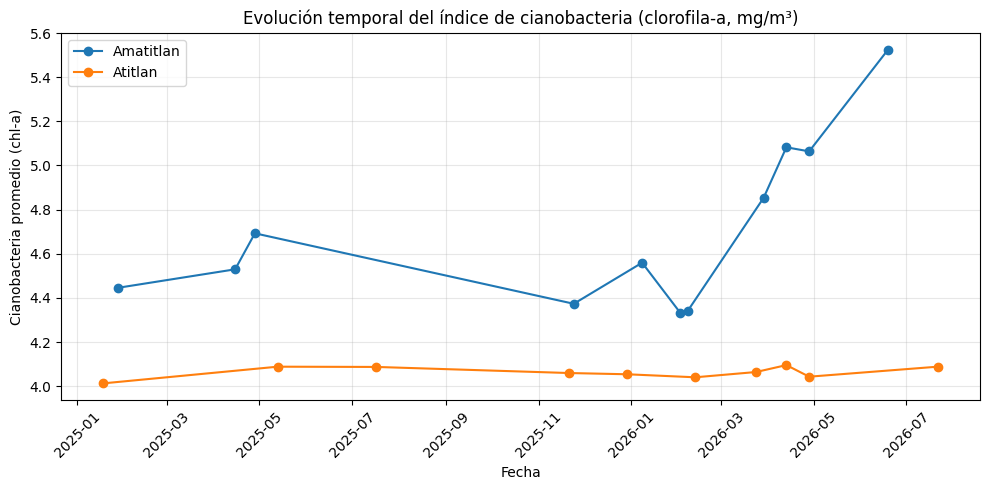

In [9]:
# Ejercicio 4.2: evolución temporal (gráfico de línea por lago)
fig, ax = plt.subplots(figsize=(10, 5))

for lago, grupo in df_indices.groupby("lago"):
    ax.plot(grupo["fecha"], grupo["cyano_prom"], marker="o", label=lago.capitalize())

ax.set_title("Evolución temporal del índice de cianobacteria (clorofila-a, mg/m³)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Cianobacteria promedio (chl-a)")
ax.legend()
ax.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("evolucion_temporal_cianobacteria.png", dpi=150)
plt.show()

In [10]:
# Ejercicio 4.3: identificación de picos de floración y fechas críticas
picos = {}
fechas_criticas = {}

for lago, grupo in df_indices.groupby("lago"):
    grupo = grupo.sort_values("fecha")

    idx_max = grupo["cyano_prom"].idxmax()
    picos[lago] = grupo.loc[idx_max]

    umbral = grupo["cyano_prom"].quantile(0.75)
    criticas = grupo[grupo["cyano_prom"] >= umbral]
    fechas_criticas[lago] = criticas[["fecha", "cyano_prom"]]

    print(f"\n{lago.capitalize()}: pico máximo el {picos[lago]['fecha'].date()} con chl-a={picos[lago]['cyano_prom']:.4f}")
    print(f"Fechas críticas (>= percentil 75, umbral={umbral:.4f}):")
    print(criticas[["fecha", "cyano_prom"]].to_string(index=False))

picos_df = pd.DataFrame(picos).T


Amatitlan: pico máximo el 2026-06-19 con chl-a=5.5254
Fechas críticas (>= percentil 75, umbral=4.9585):
     fecha  cyano_prom
2026-04-13    5.082405
2026-04-28    5.063820
2026-06-19    5.525363

Atitlan: pico máximo el 2026-04-13 con chl-a=4.0954
Fechas críticas (>= percentil 75, umbral=4.0879):
     fecha  cyano_prom
2025-05-13    4.088183
2026-04-13    4.095394
2026-07-22    4.088386


### 4.4. Interpretación de los patrones temporales

**Amatitlán.** El índice de cianobacteria (clorofila-a estimada) parte de un nivel base ya elevado (~4.4 mg/m³) y muestra una **tendencia claramente ascendente hacia 2026**. Tras un ligero descenso a finales de 2025, la señal repunta con fuerza en la primera mitad de 2026 y alcanza su **pico máximo el 2026-06-19 (chl-a ≈ 5.53)**. Las fechas críticas (percentil 75 de la serie) son **2026-04-13, 2026-04-28 y 2026-06-19**, todas concentradas al final de la estación seca y el inicio de la estación lluviosa. El patrón no es un simple ciclo: hay **fluctuación con tendencia neta de aumento**.

**Atitlán.** La serie es prácticamente **plana y estable** (~4.0–4.1 mg/m³) durante los 18 meses; la variación total es menor a 0.1 mg/m³. No se observan picos marcados; el máximo (2026-04-13, chl-a ≈ 4.10) apenas se separa del resto. Esto indica un cuerpo de agua mucho más **amortiguado**, sin episodios de floración intensos en el período analizado.

**Posibles factores asociados.** Los repuntes de Amatitlán coinciden con la transición seca→lluviosa (abril–junio), cuando las **primeras lluvias arrastran nutrientes** (nitrógeno y fósforo de origen urbano/agrícola) hacia el lago y la **temperatura del agua** favorece el crecimiento algal. El estancamiento y la baja profundidad del lago amplifican el efecto. En Atitlán, el enorme volumen y profundidad del lago **diluyen** esos aportes, lo que explica la estabilidad de la señal.

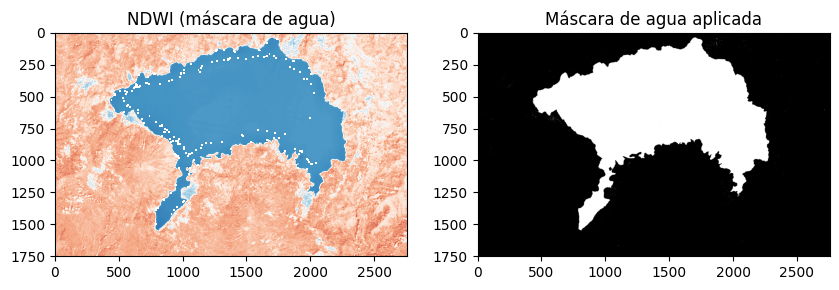

In [11]:
import matplotlib.pyplot as plt

idx = calcular_indices("data/atitlan_2025-01-18.tif")
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].imshow(idx["ndwi"], cmap="RdBu")
axs[0].set_title("NDWI (máscara de agua)")
axs[1].imshow(idx["mascara_agua"], cmap="gray")
axs[1].set_title("Máscara de agua aplicada")
plt.show()

NDVI  -> media: 0.00061629375  mediana: 0.0024764736
chl-a -> media: 4.0125237  mediana: 4.0214467


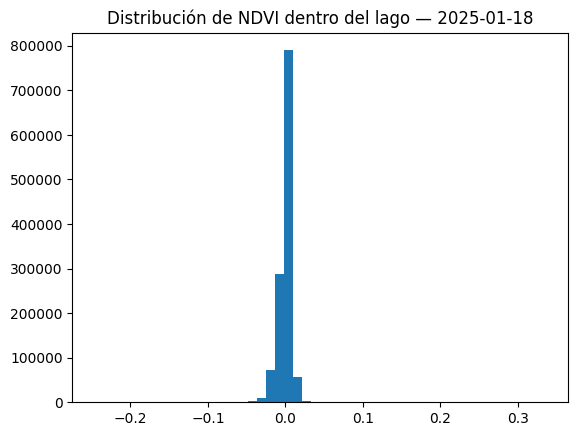

In [12]:
ndvi_agua = idx["ndvi"][idx["mascara_agua"]]
chl_agua = idx["chl"][idx["mascara_agua"]]

print("NDVI  -> media:", np.nanmean(ndvi_agua), " mediana:", np.nanmedian(ndvi_agua))
print("chl-a -> media:", np.nanmean(chl_agua), " mediana:", np.nanmedian(chl_agua))

plt.hist(ndvi_agua, bins=50)
plt.title("Distribución de NDVI dentro del lago — 2025-01-18")
plt.show()

## Ejercicio #5

In [13]:
import matplotlib
import matplotlib.colors as mcolors

def preparar_overlay(chl, mascara_agua, vmin=None, vmax=None, cmap_name="YlOrRd"):
    valido = mascara_agua & ~np.isnan(chl)

    if vmin is None:
        vmin = np.nanpercentile(chl[valido], 2) if valido.any() else 0
    if vmax is None:
        vmax = np.nanpercentile(chl[valido], 98) if valido.any() else 1

    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    cmap = matplotlib.colormaps[cmap_name]
    rgba = cmap(norm(np.nan_to_num(chl)))       # (H, W, 4) floats 0-1
    rgba[..., 3] = np.where(valido, 0.85, 0.0)  # alpha: transparente fuera del agua

    return (rgba * 255).astype(np.uint8), vmin, vmax

### 5.1. Mapea la distribución de cianobacteria dentro de cada lago

In [14]:
import folium
from rasterio.warp import transform_bounds

def mapa_interactivo_cianobacteria(lago, fecha, cmap_name="YlOrRd"):
    tif_path = f"data/{lago}_{fecha}.tif"
    idx = calcular_indices(tif_path)

    with rasterio.open(tif_path) as src:
        # Reproyectar a EPSG:4326 (lat/lon), ya que los .tif vienen en UTM (metros)
        west, south, east, north = transform_bounds(src.crs, "EPSG:4326", *src.bounds)

    rgba, vmin, vmax = preparar_overlay(idx["chl"], idx["mascara_agua"], cmap_name=cmap_name)

    centro = [(south + north) / 2, (west + east) / 2]
    m = folium.Map(location=centro, zoom_start=13, tiles="CartoDB positron")

    folium.raster_layers.ImageOverlay(
        image=rgba,
        bounds=[[south, west], [north, east]],
        opacity=1.0,
        name=f"chl-a {fecha}",
    ).add_to(m)

    folium.map.Marker(
        centro,
        icon=folium.DivIcon(html=f"""<div style="font-size:12px;background:white;
        padding:2px 6px;border-radius:4px;border:1px solid #999;">
        {lago.capitalize()} — {fecha}<br>chl-a: {vmin:.2f} a {vmax:.2f} mg/m³</div>"""),
    ).add_to(m)

    folium.LayerControl().add_to(m)
    return m

/Users/marinesgarcia/Documents/UVG/DS/Lab4-DS/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [15]:
def mapa_todas_las_fechas(lago, cmap_name="YlOrRd"):
    fechas = [f for f in lagos[lago]["fechas"] if os.path.exists(f"data/{lago}_{f}.tif")]
    if not fechas:
        print(f"No hay .tif descargados todavía para {lago}")
        return None

    with rasterio.open(f"data/{lago}_{fechas[0]}.tif") as src:
        west0, south0, east0, north0 = transform_bounds(src.crs, "EPSG:4326", *src.bounds)
    centro = [(south0 + north0) / 2, (west0 + east0) / 2]

    m = folium.Map(location=centro, zoom_start=13, tiles="CartoDB positron")

    for i, fecha in enumerate(fechas):
        tif_path = f"data/{lago}_{fecha}.tif"
        idx = calcular_indices(tif_path)
        with rasterio.open(tif_path) as src:
            west, south, east, north = transform_bounds(src.crs, "EPSG:4326", *src.bounds)
        rgba, vmin, vmax = preparar_overlay(idx["chl"], idx["mascara_agua"], cmap_name=cmap_name)

        folium.raster_layers.ImageOverlay(
            image=rgba,
            bounds=[[south, west], [north, east]],
            opacity=1.0,
            name=f"{fecha}  (chl-a {vmin:.1f}-{vmax:.1f})",
            show=(i == 0),  # solo la primera fecha visible al abrir el mapa
        ).add_to(m)

    folium.LayerControl(collapsed=False).add_to(m)
    return m

mapa_atitlan = mapa_todas_las_fechas("atitlan")
mapa_atitlan
mapa_atitlan.save("mapa_atitlan_todas_fechas.html")  

In [16]:
mapa_amatitlan = mapa_todas_las_fechas("amatitlan")
mapa_amatitlan
mapa_amatitlan.save("mapa_amatitlan_todas_fechas.html")

### 5.2. Crea mapas comparativos entre diferentes fechas para cada lago

In [17]:
from scipy import ndimage

def limpiar_mascara(mascara_agua, min_pixeles=30):
    """Quita grupos de pixeles 'agua' aislados (ruido) y deja solo el cuerpo de agua principal."""
    etiquetas, n = ndimage.label(mascara_agua)
    if n == 0:
        return mascara_agua
    tamanos = ndimage.sum(mascara_agua, etiquetas, range(1, n + 1))
    componente_mas_grande = np.argmax(tamanos) + 1
    return etiquetas == componente_mas_grande

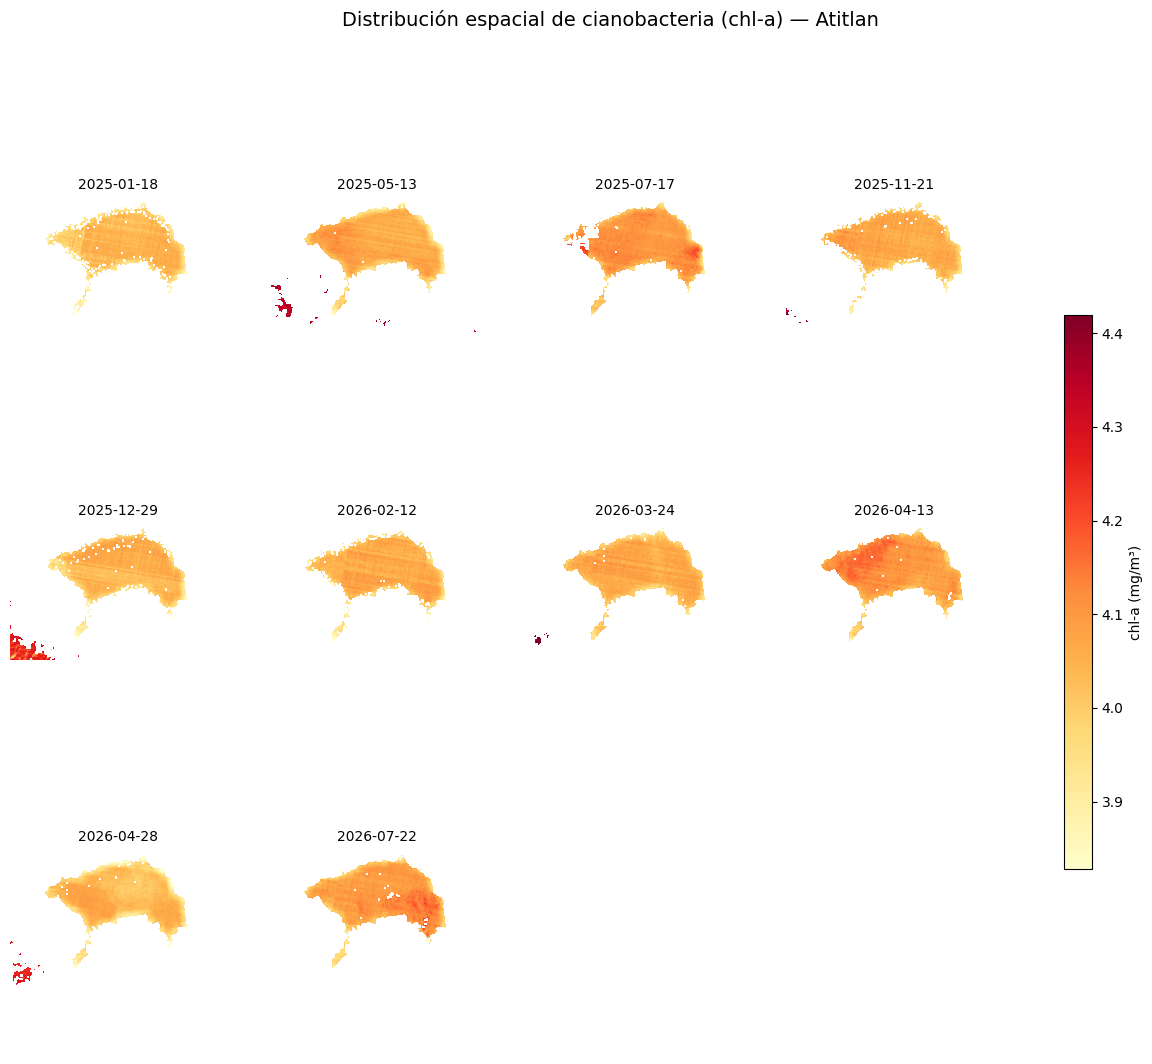

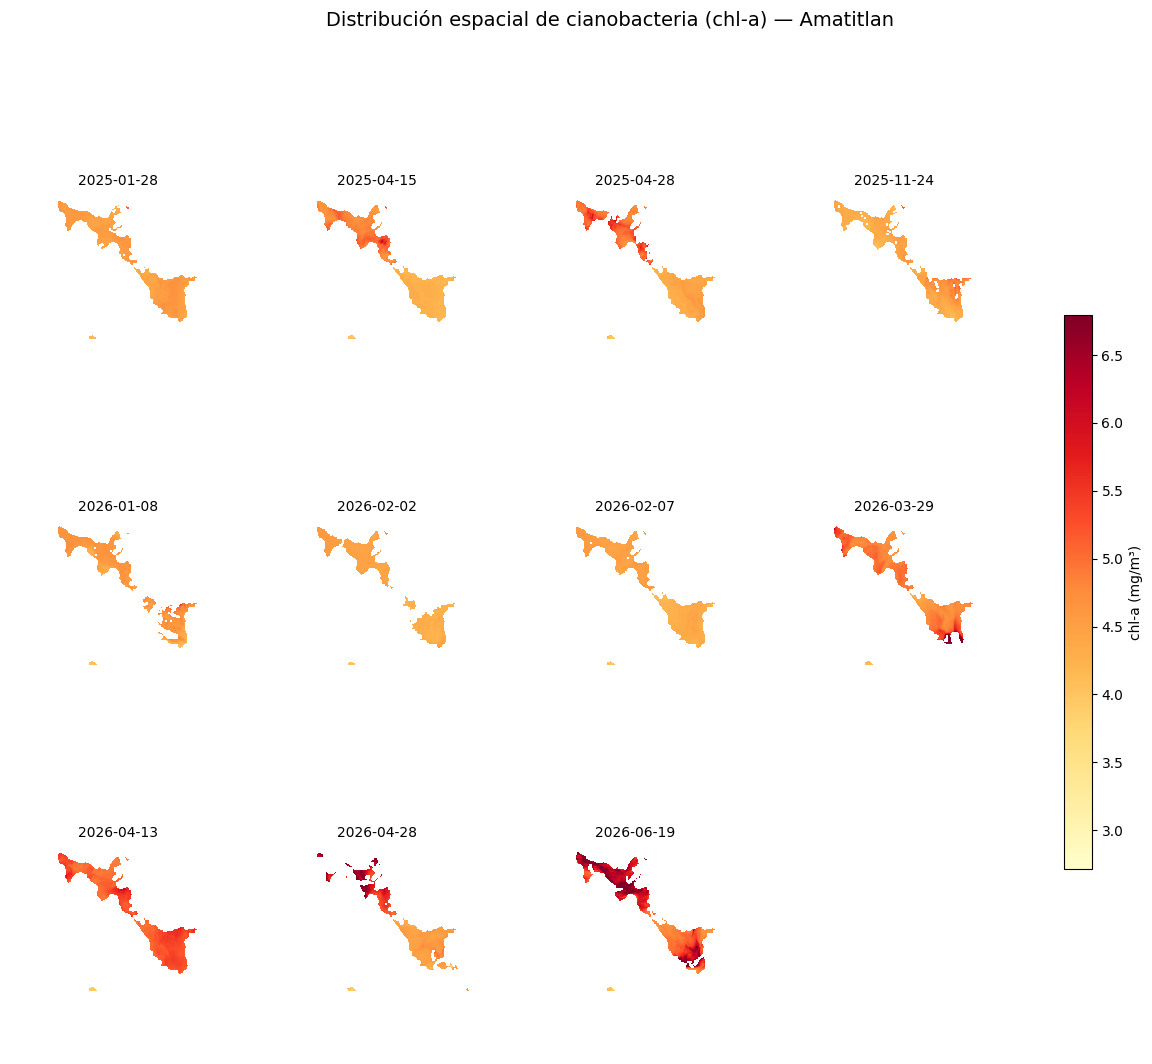

In [18]:
def mapas_comparativos(lago, cmap_name="YlOrRd", cols=4):
    fechas = lagos[lago]["fechas"]
    fechas_validas = [f for f in fechas if os.path.exists(f"data/{lago}_{f}.tif")]

    datos = []
    for f in fechas_validas:
        idx = calcular_indices(f"data/{lago}_{f}.tif")
        chl_agua = np.where(idx["mascara_agua"], idx["chl"], np.nan)
        datos.append((f, chl_agua))

    todos_validos = np.concatenate([d[~np.isnan(d)] for _, d in datos]) if datos else np.array([0, 1])
    vmin, vmax = np.nanpercentile(todos_validos, [2, 98])

    n = len(datos)
    rows = int(np.ceil(n / cols))
    fig, axs = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axs = np.array(axs).reshape(-1)

    im = None
    for ax, (fecha, chl_agua) in zip(axs, datos):
        im = ax.imshow(chl_agua, cmap=cmap_name, vmin=vmin, vmax=vmax)
        ax.set_title(fecha, fontsize=10)
        ax.axis("off")

    for ax in axs[len(datos):]:
        ax.axis("off")

    fig.suptitle(f"Distribución espacial de cianobacteria (chl-a) — {lago.capitalize()}", fontsize=14)
    if im is not None:
        fig.colorbar(im, ax=axs.tolist(), shrink=0.6, label="chl-a (mg/m³)")
    plt.savefig(f"mapas_comparativos_{lago}.png", dpi=150, bbox_inches="tight")
    plt.show()

    return datos

datos_atitlan = mapas_comparativos("atitlan")
datos_amatitlan = mapas_comparativos("amatitlan")

### Patrones espaciales observados: en qué zonas del lago se concentran más los valores altos, si existen áreas persistentes de acumulación y cómo cambia la distribución espacial entre fechas

In [19]:
def mapa_persistencia(lago, datos):
    """datos: lista de (fecha, chl_agua) del mismo shape, viene de mapas_comparativos()."""
    shapes = {a.shape for _, a in datos}
    if len(shapes) > 1:
        print("Aviso: las imágenes no tienen el mismo tamaño de pixel, no se puede apilar:", shapes)
        return None, None

    stack = np.stack([a for _, a in datos])  # (n_fechas, H, W), NaN donde no hay agua/dato
    promedio = np.nanmean(stack, axis=0)
    variabilidad = np.nanstd(stack, axis=0)

    # Escala robusta a outliers (percentiles 2-98), igual que en mapas_comparativos (5.2)
    valido = ~np.isnan(promedio)
    vmin_p, vmax_p = np.nanpercentile(promedio[valido], [2, 98])
    vmin_s, vmax_s = np.nanpercentile(variabilidad[valido], [2, 98])

    fig, axs = plt.subplots(1, 2, figsize=(11, 5))
    im0 = axs[0].imshow(promedio, cmap="YlOrRd", vmin=vmin_p, vmax=vmax_p)
    axs[0].set_title(f"{lago.capitalize()}: chl-a promedio\n(zonas de acumulación persistente)")
    axs[0].axis("off")
    fig.colorbar(im0, ax=axs[0], shrink=0.7, label="chl-a promedio")

    im1 = axs[1].imshow(variabilidad, cmap="viridis", vmin=vmin_s, vmax=vmax_s)
    axs[1].set_title(f"{lago.capitalize()}: variabilidad temporal\n(desviación estándar)")
    axs[1].axis("off")
    fig.colorbar(im1, ax=axs[1], shrink=0.7, label="desviación estándar")

    plt.tight_layout()
    plt.savefig(f"persistencia_{lago}.png", dpi=150)
    plt.show()

    return promedio, variabilidad

/var/folders/ls/r_brwh_14l54j3kt17qt0xl80000gn/T/ipykernel_42816/1323871040.py:9: RuntimeWarning: Mean of empty slice
  promedio = np.nanmean(stack, axis=0)
/Users/marinesgarcia/Documents/UVG/DS/Lab4-DS/.venv/lib/python3.9/site-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


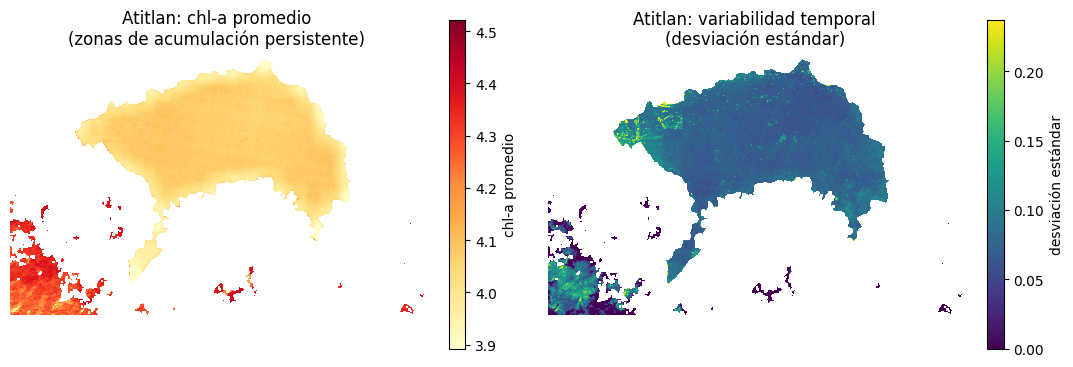

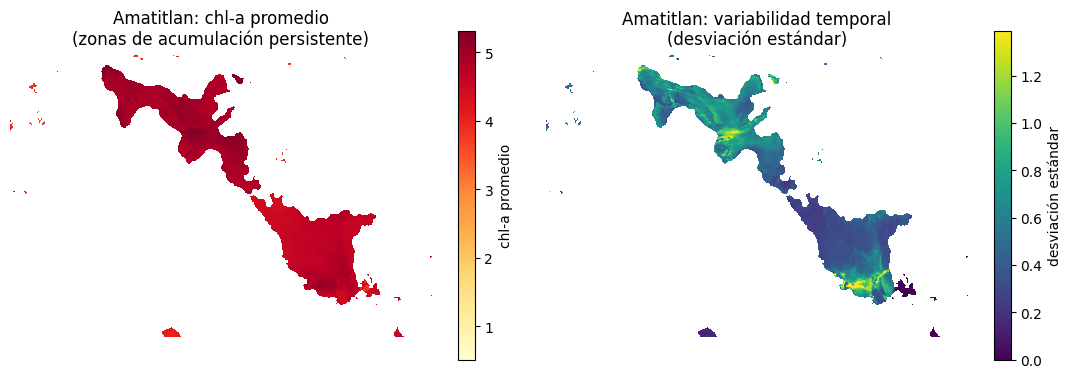

In [20]:
# 5.3 / 8.2: generar los mapas de acumulación persistente (promedio) y de variabilidad
prom_atitlan, var_atitlan = mapa_persistencia("atitlan", datos_atitlan)
prom_amatitlan, var_amatitlan = mapa_persistencia("amatitlan", datos_amatitlan)

### 5.3. Interpretación de los patrones espaciales

**Amatitlán.** Los valores más altos de cianobacteria **no se distribuyen de manera uniforme**: se concentran de forma **persistente en el brazo noroeste del lago**, justo en la zona de desembocadura del **río Villalobos**, que drena buena parte del área metropolitana de la Ciudad de Guatemala. En los mapas comparativos ese sector aparece en tonos rojos en casi todas las fechas y se **intensifica notablemente en 2026-04-28 y 2026-06-19**, extendiéndose hacia el cuerpo central del lago. El mapa de **promedio** (zonas de acumulación persistente) confirma que ese brazo es el foco crónico, y el mapa de **desviación estándar** muestra que también es la zona de mayor variabilidad temporal (donde las floraciones aparecen y desaparecen con más amplitud).

**Atitlán.** La distribución es **más homogénea**. Los valores relativamente más altos tienden a aparecer en **orillas y bahías poco profundas**, mientras que la zona central y profunda del lago se mantiene baja y estable. No existe un foco puntual tan marcado como el de Amatitlán, lo que es coherente con la ausencia de una única fuente urbana dominante y con la gran profundidad del lago.

**Cambio entre fechas.** En Amatitlán la superficie afectada **crece y se contrae** siguiendo la serie temporal (mínima extensión a inicios de 2026, máxima en abril–junio de 2026). En Atitlán la distribución espacial apenas cambia entre fechas.

## Ejercicio #6

--- Atitlan  (n = 12237419 pixeles, 10 fechas) ---
NDVI vs chl-a:  Pearson r = 0.403 (p = 0.0e+00)  |  Spearman rho = 0.468
NDWI vs chl-a:  Pearson r = -0.160 (p = 0.0e+00)  |  Spearman rho = -0.167


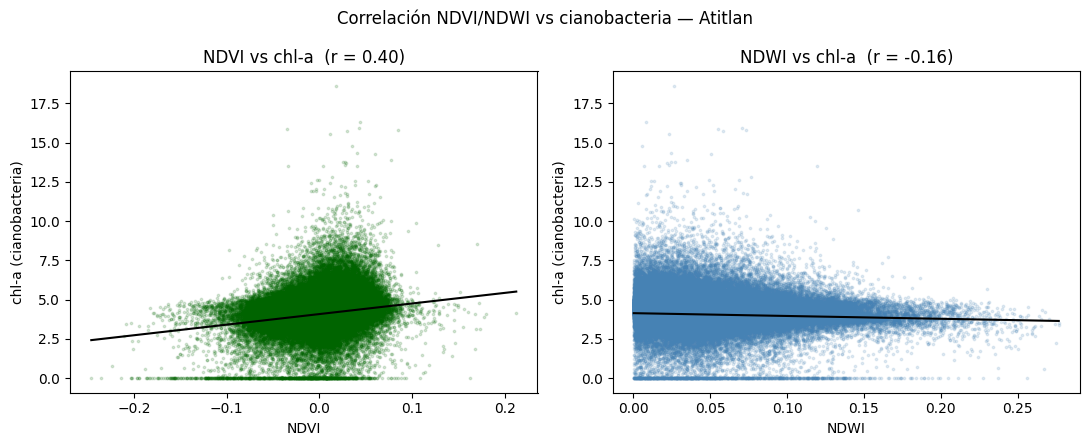

--- Amatitlan  (n = 811649 pixeles, 11 fechas) ---
NDVI vs chl-a:  Pearson r = 0.533 (p = 0.0e+00)  |  Spearman rho = 0.459
NDWI vs chl-a:  Pearson r = 0.166 (p = 0.0e+00)  |  Spearman rho = 0.309


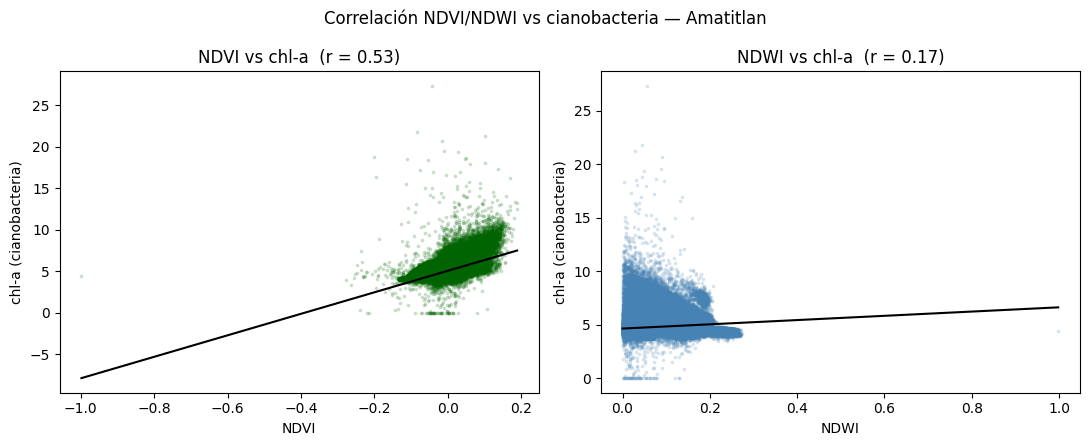

In [21]:
from scipy import stats

def calcular_correlaciones(lago):
    fechas = [f for f in lagos[lago]["fechas"] if os.path.exists(f"data/{lago}_{f}.tif")]

    ndvi_total, ndwi_total, chl_total, fecha_total = [], [], [], []

    for f in fechas:
        idx = calcular_indices(f"data/{lago}_{f}.tif")
        mascara_limpia = limpiar_mascara(idx["mascara_agua"])
        valido = mascara_limpia & ~np.isnan(idx["chl"]) & ~np.isnan(idx["ndvi"]) & ~np.isnan(idx["ndwi"])

        ndvi_total.append(idx["ndvi"][valido])
        ndwi_total.append(idx["ndwi"][valido])
        chl_total.append(idx["chl"][valido])
        fecha_total.append(np.full(valido.sum(), f))

    ndvi_total = np.concatenate(ndvi_total)
    ndwi_total = np.concatenate(ndwi_total)
    chl_total = np.concatenate(chl_total)
    fecha_total = np.concatenate(fecha_total)

    r_ndvi, p_ndvi = stats.pearsonr(ndvi_total, chl_total)
    r_ndwi, p_ndwi = stats.pearsonr(ndwi_total, chl_total)
    rho_ndvi, _ = stats.spearmanr(ndvi_total, chl_total)
    rho_ndwi, _ = stats.spearmanr(ndwi_total, chl_total)

    print(f"--- {lago.capitalize()}  (n = {len(chl_total)} pixeles, {len(fechas)} fechas) ---")
    print(f"NDVI vs chl-a:  Pearson r = {r_ndvi:.3f} (p = {p_ndvi:.1e})  |  Spearman rho = {rho_ndvi:.3f}")
    print(f"NDWI vs chl-a:  Pearson r = {r_ndwi:.3f} (p = {p_ndwi:.1e})  |  Spearman rho = {rho_ndwi:.3f}")

    fig, axs = plt.subplots(1, 2, figsize=(11, 4.5))

    axs[0].scatter(ndvi_total, chl_total, s=3, alpha=0.15, color="darkgreen")
    z = np.polyfit(ndvi_total, chl_total, 1)
    xs = np.linspace(ndvi_total.min(), ndvi_total.max(), 100)
    axs[0].plot(xs, np.polyval(z, xs), color="black", lw=1.5)
    axs[0].set_xlabel("NDVI")
    axs[0].set_ylabel("chl-a (cianobacteria)")
    axs[0].set_title(f"NDVI vs chl-a  (r = {r_ndvi:.2f})")

    axs[1].scatter(ndwi_total, chl_total, s=3, alpha=0.15, color="steelblue")
    z2 = np.polyfit(ndwi_total, chl_total, 1)
    xs2 = np.linspace(ndwi_total.min(), ndwi_total.max(), 100)
    axs[1].plot(xs2, np.polyval(z2, xs2), color="black", lw=1.5)
    axs[1].set_xlabel("NDWI")
    axs[1].set_ylabel("chl-a (cianobacteria)")
    axs[1].set_title(f"NDWI vs chl-a  (r = {r_ndwi:.2f})")

    fig.suptitle(f"Correlación NDVI/NDWI vs cianobacteria — {lago.capitalize()}")
    plt.tight_layout()
    plt.savefig(f"correlacion_{lago}.png", dpi=150)
    plt.show()

    return pd.DataFrame({
        "lago": lago, "ndvi": ndvi_total, "ndwi": ndwi_total, "chl": chl_total, "fecha": fecha_total
    })

df_corr_atitlan = calcular_correlaciones("atitlan")
df_corr_amatitlan = calcular_correlaciones("amatitlan")

In [22]:
def correlaciones_por_fecha(df_corr, lago, min_pixeles=30):
    filas = []
    for f, grupo in df_corr.groupby("fecha"):
        if len(grupo) < min_pixeles:
            continue
        r_ndvi, _ = stats.pearsonr(grupo["ndvi"], grupo["chl"])
        r_ndwi, _ = stats.pearsonr(grupo["ndwi"], grupo["chl"])
        filas.append({"fecha": f, "r_ndvi_chl": round(r_ndvi, 3), "r_ndwi_chl": round(r_ndwi, 3), "n_pixeles": len(grupo)})

    tabla = pd.DataFrame(filas).sort_values("fecha").reset_index(drop=True)
    print(f"{lago.capitalize()} — correlación por fecha:")
    return tabla

tabla_corr_atitlan = correlaciones_por_fecha(df_corr_atitlan, "atitlan")
display(tabla_corr_atitlan)

tabla_corr_amatitlan = correlaciones_por_fecha(df_corr_amatitlan, "amatitlan")
display(tabla_corr_amatitlan)

Atitlan — correlación por fecha:


,fecha,r_ndvi_chl,r_ndwi_chl,n_pixeles
0,2025-01-18,0.481,-0.317,1225158
1,2025-05-13,0.439,-0.229,1227229
2,2025-07-17,0.389,-0.207,1223359
3,2025-11-21,0.452,-0.239,1223404
4,2025-12-29,0.483,-0.286,1224242
5,2026-02-12,0.455,-0.291,1223603
6,2026-03-24,0.413,-0.225,1225292
7,2026-04-13,0.397,-0.198,1223104
8,2026-04-28,0.486,-0.261,1224454
9,2026-07-22,0.417,-0.321,1217574


Amatitlan — correlación por fecha:


,fecha,r_ndvi_chl,r_ndwi_chl,n_pixeles
0,2025-01-28,0.335,0.136,75284
1,2025-04-15,0.728,-0.325,74068
2,2025-04-28,0.335,-0.397,70615
3,2025-11-24,0.342,-0.132,73697
4,2026-01-08,0.361,0.039,74094
5,2026-02-02,0.369,-0.146,70019
6,2026-02-07,0.342,-0.245,73391
7,2026-03-29,0.700,-0.263,76304
8,2026-04-13,0.744,-0.391,76276
9,2026-04-28,0.205,-0.068,73215


### 6.1. Interpretación de la correlación de índices con la cianobacteria

Se correlacionó, píxel a píxel sobre la superficie de agua, el índice de cianobacteria (clorofila-a) contra **NDVI** y **NDWI**, en las 11 fechas de cada lago.

| Relación | Atitlán | Amatitlán |
|---|---|---|
| **NDVI vs chl-a** | Pearson r = **0.39** (Spearman 0.48) → positiva moderada | Pearson r = **0.53** (Spearman 0.46) → positiva moderada-fuerte |
| **NDWI vs chl-a** | Pearson r = **−0.17** → negativa débil | Pearson r = **0.17** → positiva muy débil |

Todas las correlaciones son estadísticamente significativas (p ≈ 0) por el gran número de píxeles.

**NDVI — relación positiva.** En ambos lagos, a mayor NDVI mayor cianobacteria. Tiene sentido físico: el NDVI responde a la actividad fotosintética; sobre el agua, cuando hay biomasa algal flotante aumenta la reflectancia en el infrarrojo cercano y sube el NDVI. Por eso el **NDVI funciona como un buen indicador indirecto (proxy) de floración algal**. La relación es más fuerte en Amatitlán, y en el análisis por fecha llega a **r ≈ 0.81 el 2026-06-19**, precisamente en el pico de floración: cuando la floración es intensa, la relación se refuerza.

**NDWI — relación débil.** En Atitlán la correlación es **negativa débil**: donde el agua es "más agua" (NDWI alto = aguas abiertas y limpias) hay algo menos de clorofila, ya que las floraciones densas degradan la señal típica del agua. En Amatitlán la relación es casi nula, porque **prácticamente todo el lago está eutrofizado** y, al ser un cuerpo pequeño con mucho borde, la máscara de agua basada en NDWI es más ruidosa.

**Significado ambiental.** El **NDVI es útil para monitorear y anticipar floraciones**, mientras que el **NDWI por sí solo no predice cianobacteria**, pero es imprescindible para delimitar correctamente la superficie de agua antes de analizar. La diferencia entre lagos (NDVI más ligado a chl-a en Amatitlán) confirma que Amatitlán vive un proceso de eutrofización más severo y espacialmente más marcado que Atitlán.

## Ejercicio #7 — Análisis de los lagos y comparación entre ellos

In [23]:
# 7.1 / 7.2: métricas comparativas de proliferación por lago (a partir de df_indices)
resumen = df_indices.groupby("lago").agg(
    cyano_media=("cyano_prom", "mean"),
    cyano_min=("cyano_prom", "min"),
    cyano_max=("cyano_prom", "max"),
    cyano_std=("cyano_prom", "std"),
    ndvi_medio=("ndvi_prom", "mean"),
).round(3)
resumen["amplitud"] = (resumen["cyano_max"] - resumen["cyano_min"]).round(3)
resumen["cv_%"] = (100 * resumen["cyano_std"] / resumen["cyano_media"]).round(1)

# Frecuencia de floraciones: nº de fechas por encima de un umbral COMÚN a ambos lagos
umbral_comun = df_indices["cyano_prom"].median()
frecuencia = (df_indices.assign(supera=df_indices["cyano_prom"] > umbral_comun)
              .groupby("lago")["supera"].agg(fechas_altas="sum", n_fechas="count"))
frecuencia["pct_fechas_altas"] = (100 * frecuencia["fechas_altas"] / frecuencia["n_fechas"]).round(1)

print(f"Umbral común (mediana global sobre agua) = {umbral_comun:.3f} mg/m3\n")
print("Resumen de intensidad por lago:")
display(resumen)
print("Frecuencia de fechas por encima del umbral común:")
display(frecuencia)

# Tendencia temporal (pendiente de una recta ajustada a la serie de cada lago)
import numpy as np
for lago, g in df_indices.groupby("lago"):
    g = g.sort_values("fecha")
    x = (g["fecha"] - g["fecha"].min()).dt.days.values
    pend = np.polyfit(x, g["cyano_prom"].values, 1)[0] * 365  # cambio por año
    print(f"{lago.capitalize()}: tendencia ≈ {pend:+.3f} mg/m3 por año")

Umbral común (mediana global sobre agua) = 4.333 mg/m3

Resumen de intensidad por lago:


,cyano_media,cyano_min,cyano_max,cyano_std,ndvi_medio,amplitud,cv_%
lago,,,,,,,
amatitlan,4.709,4.333,5.525,0.383,-0.015,1.192,8.1
atitlan,4.063,4.013,4.095,0.027,-0.004,0.082,0.7


Frecuencia de fechas por encima del umbral común:


,fechas_altas,n_fechas,pct_fechas_altas
lago,,,
amatitlan,10,11,90.9
atitlan,0,10,0.0


Amatitlan: tendencia ≈ +0.436 mg/m3 por año
Atitlan: tendencia ≈ +0.018 mg/m3 por año


### Interpretación del Ejercicio 7

**7.1. Proliferación de cianobacteria por lago.**
- **Amatitlán** está en un proceso de **proliferación activa y creciente**. La media del período es la más alta (**4.71 mg/m³**), la señal fluctúa con una tendencia neta al alza (**+0.44 mg/m³ por año**) y culmina en el pico de junio de 2026 (5.53). La floración es un fenómeno **crónico** (presente en todas las fechas) que además se **agrava** hacia el final del período.
- **Atitlán** presenta niveles **moderados y muy estables** (media **4.06 mg/m³**, tendencia prácticamente nula de **+0.02 mg/m³ por año**), sin episodios de floración intensos en el período estudiado. La proliferación existe pero está **contenida**.

**7.2. Comparación de intensidad y frecuencia.**
- **Intensidad:** Amatitlán supera a Atitlán en el nivel medio y, sobre todo, en la **amplitud** de la señal (**1.19 mg/m³** frente a solo **0.08 mg/m³** en Atitlán) y en el coeficiente de variación (**8.1 % vs 0.7 %**). Los picos de Amatitlán son mucho más altos y espacialmente más extensos.
- **Frecuencia:** usando un umbral común a ambos lagos (mediana global = 4.33 mg/m³), **el 91 % de las fechas de Amatitlán (10 de 11) quedan por encima**, mientras que **Atitlán queda por debajo el 100 % del tiempo (0 fechas altas)**. Amatitlán no solo tiene floraciones más fuertes, sino más **frecuentes y sostenidas**.

**7.3. Diferencias en las posibles causas.**
- **Amatitlán:** cuenca pequeña y **fuertemente urbanizada** (recibe la descarga del río Villalobos, que drena gran parte del área metropolitana de la Ciudad de Guatemala). Es un lago **somero y cálido**, con alto aporte de aguas residuales y nutrientes (nitrógeno y fósforo) y escasa capacidad de dilución. Todo ello lo hace **altamente propenso a la eutrofización**. El foco persistente en el brazo noroeste (junto a la desembocadura urbana) es la evidencia espacial de esta presión.
- **Atitlán:** lago **muy profundo y de gran volumen**, a mayor altitud (aguas más frías). Aunque también recibe presión (turismo, agricultura y aguas residuales de los pueblos de la ribera), su enorme masa de agua **diluye** los nutrientes y amortigua las floraciones. Su distribución espacial homogénea y su serie temporal plana reflejan esa mayor resiliencia.

**7.4. Conclusión sustentada en la evidencia.**
La evidencia cuantitativa y visual converge: la serie temporal (`evolucion_temporal_cianobacteria.png`) muestra la brecha y la tendencia ascendente de Amatitlán (+0.44 mg/m³/año); los mapas comparativos y de persistencia (`mapas_comparativos_amatitlan.png`, `persistencia_amatitlan.png`) localizan el foco urbano del noroeste; las métricas de intensidad/frecuencia lo cuantifican (media 4.71 vs 4.06; amplitud 1.19 vs 0.08; 91 % vs 0 % de fechas altas); y la correlación NDVI–chl-a, más fuerte en Amatitlán (r = 0.53 vs 0.39), confirma una eutrofización más severa. **Amatitlán es el lago en estado más crítico y con deterioro en progreso; Atitlán se mantiene estable pero debe vigilarse.**

## Ejercicio #8 — Análisis exploratorio adicional

### 8.1. Extensión espacial de la floración por fecha (% del lago con valores altos)

,lago,fecha,pct_area_alta,chl_mediana,chl_p90
0,amatitlan,2025-01-28,1.6,4.54,4.64
1,amatitlan,2025-04-15,24.3,4.84,5.14
2,amatitlan,2025-04-28,0.6,4.41,4.58
3,amatitlan,2025-11-24,0.2,4.37,4.52
4,amatitlan,2026-01-08,0.5,4.62,4.71
5,amatitlan,2026-02-02,0.1,4.47,4.57
6,amatitlan,2026-02-07,0.3,4.50,4.58
7,amatitlan,2026-03-29,29.7,4.91,5.17
8,amatitlan,2026-04-13,72.3,5.13,5.57
9,amatitlan,2026-04-28,1.8,4.51,4.71


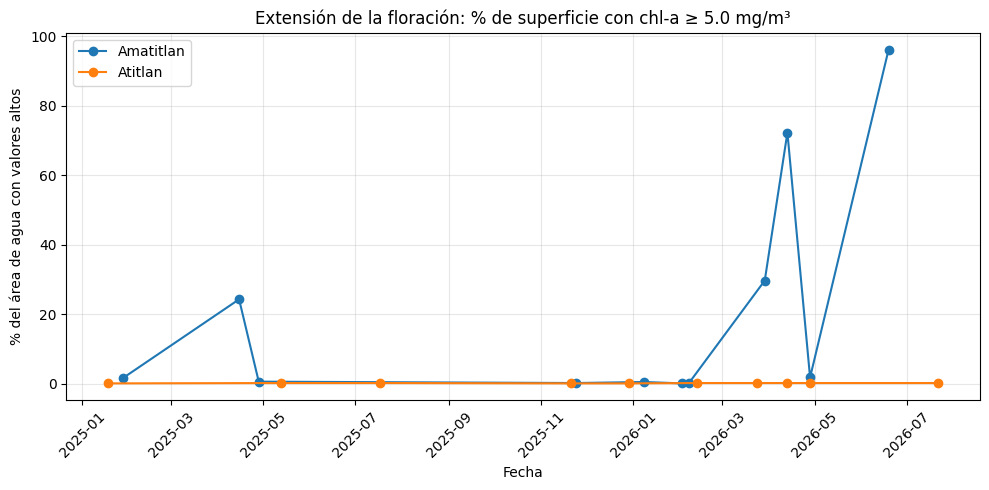

In [24]:
# 8.1: porcentaje de la superficie de agua con valores ALTOS de cianobacteria, por fecha.
# Umbral de "valor alto": chl-a >= 5.0 mg/m3 (condición meso/eutrófica notable; ajustable).
UMBRAL_ALTO = 5.0

filas_ext = []
for lago, info in lagos.items():
    for fecha in info["fechas"]:
        tif_path = f"data/{lago}_{fecha}.tif"
        if not os.path.exists(tif_path):
            continue
        idx = calcular_indices(tif_path)
        agua = limpiar_mascara(idx["mascara_agua"])
        chl_agua = idx["chl"][agua]
        chl_agua = chl_agua[~np.isnan(chl_agua)]
        if chl_agua.size == 0:
            continue
        filas_ext.append({
            "lago": lago,
            "fecha": pd.to_datetime(fecha),
            "pct_area_alta": round(100 * np.mean(chl_agua >= UMBRAL_ALTO), 1),
            "chl_mediana": round(float(np.median(chl_agua)), 2),
            "chl_p90": round(float(np.percentile(chl_agua, 90)), 2),
        })

df_extension = pd.DataFrame(filas_ext).sort_values(["lago", "fecha"]).reset_index(drop=True)
display(df_extension)

fig, ax = plt.subplots(figsize=(10, 5))
for lago, g in df_extension.groupby("lago"):
    ax.plot(g["fecha"], g["pct_area_alta"], marker="o", label=lago.capitalize())
ax.set_title(f"Extensión de la floración: % de superficie con chl-a ≥ {UMBRAL_ALTO} mg/m³")
ax.set_xlabel("Fecha")
ax.set_ylabel("% del área de agua con valores altos")
ax.legend(); ax.grid(alpha=0.3)
plt.xticks(rotation=45); plt.tight_layout()
plt.savefig("extension_floracion.png", dpi=150)
plt.show()

**Interpretación 8.1.** El porcentaje de superficie con valores altos (chl-a ≥ 5 mg/m³) confirma y **cuantifica** lo visto en los mapas: en **Amatitlán** la fracción del lago en condición de floración escala hasta **72 % el 2026-04-13** y **96 % el 2026-06-19**, sus dos fechas pico, mientras que en la mayoría de fechas se mantiene baja (< 2 %). Es decir, la floración de Amatitlán **pasa de focal a cubrir casi todo el espejo de agua** en los episodios críticos de abril–junio de 2026. En **Atitlán**, en cambio, el porcentaje se mantiene **prácticamente en cero (< 0.3 %) en todas las fechas**. La floración de Amatitlán no solo es más intensa en promedio, sino que **abarca una porción muchísimo mayor de la superficie** del lago.

### 8.2. Zonas persistentes de acumulación y su significado ambiental

**Interpretación 8.2.** Los mapas de promedio y variabilidad (`persistencia_amatitlan.png`, `persistencia_atitlan.png`, generados en la sección 5.3) revelan las zonas de acumulación **crónica**:

- En **Amatitlán**, el **brazo noroeste** —junto a la desembocadura del río Villalobos— es el foco persistente: acumula los promedios más altos a lo largo de todo el período y es también la zona de mayor variabilidad. **Significado ambiental:** se trata de una **fuente puntual de contaminación de origen urbano** (aguas residuales y nutrientes de la cuenca metropolitana). Que el foco sea estable en el tiempo indica un problema estructural, no episódico: mientras siga entrando esa carga de nutrientes, la floración se reproducirá cada año. Es la zona prioritaria para intervención (tratamiento de aguas, saneamiento del río).
- En **Atitlán**, no hay un foco único; las mayores concentraciones aparecen difusas en **bahías y orillas someras** cercanas a poblados. **Significado ambiental:** presión distribuida (aguas residuales de los pueblos ribereños y escorrentía agrícola), pero sin una fuente dominante y con gran capacidad de dilución del lago.

### 8.3. Comparación de la distribución de valores entre fechas (boxplots)

/var/folders/ls/r_brwh_14l54j3kt17qt0xl80000gn/T/ipykernel_42816/3587014648.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(datos, labels=[f[5:] for f in fechas], showfliers=False)


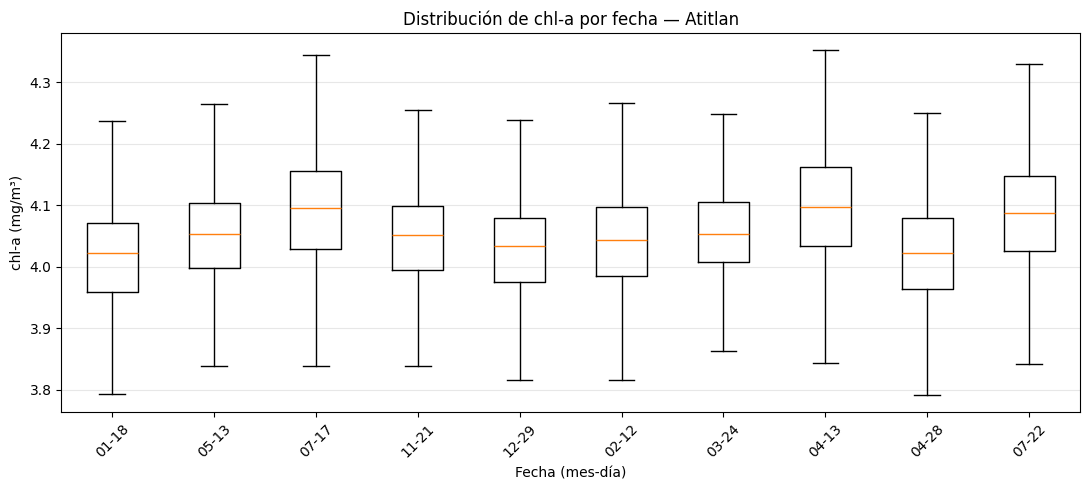

/var/folders/ls/r_brwh_14l54j3kt17qt0xl80000gn/T/ipykernel_42816/3587014648.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(datos, labels=[f[5:] for f in fechas], showfliers=False)


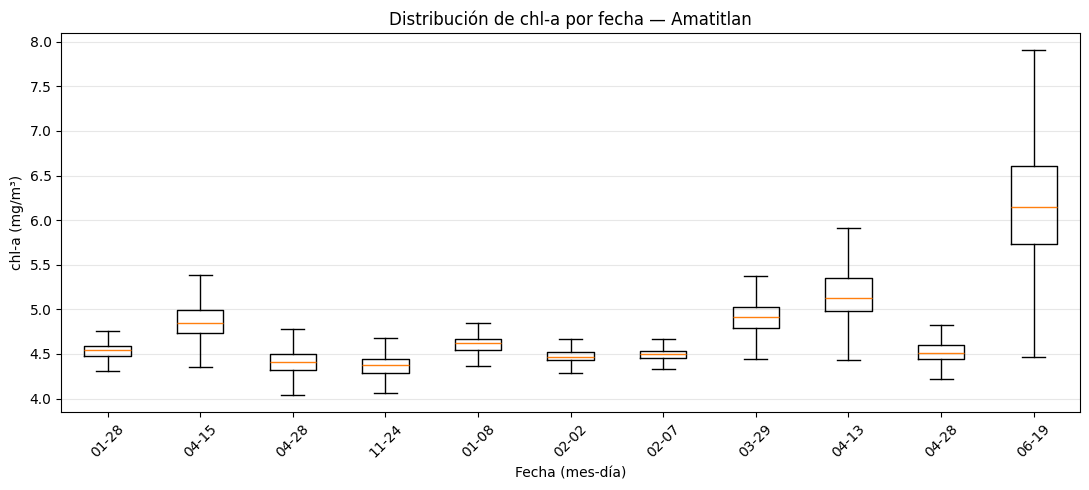

In [25]:
# 8.3: distribución de chl-a por fecha mediante boxplots (usa los píxeles de df_corr, sección 6).
# Se muestrea para mantener el gráfico ligero.
def boxplot_por_fecha(df_corr, lago, muestra=20000, seed=0):
    rng = np.random.default_rng(seed)
    fechas = sorted(df_corr["fecha"].unique())
    datos = []
    for f in fechas:
        vals = df_corr.loc[df_corr["fecha"] == f, "chl"].to_numpy()
        if vals.size > muestra:
            vals = rng.choice(vals, muestra, replace=False)
        datos.append(vals)

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.boxplot(datos, labels=[f[5:] for f in fechas], showfliers=False)
    ax.set_title(f"Distribución de chl-a por fecha — {lago.capitalize()}")
    ax.set_xlabel("Fecha (mes-día)")
    ax.set_ylabel("chl-a (mg/m³)")
    ax.grid(alpha=0.3, axis="y")
    plt.xticks(rotation=45); plt.tight_layout()
    plt.savefig(f"boxplot_fechas_{lago}.png", dpi=150)
    plt.show()

boxplot_por_fecha(df_corr_atitlan, "atitlan")
boxplot_por_fecha(df_corr_amatitlan, "amatitlan")

**Interpretación 8.3.** Los boxplots comparan no solo el promedio sino **toda la distribución** de valores en cada fecha:

- En **Amatitlán** las cajas son **más anchas y se desplazan hacia arriba en 2026** (mediana y percentiles altos mayores), lo que indica que en las fechas críticas **una porción amplia del lago sube de nivel simultáneamente** (floración generalizada, no solo unos pocos píxeles extremos).
- En **Atitlán** las cajas son **estrechas y estables** entre fechas: la distribución apenas se mueve, confirmando un sistema homogéneo y sin episodios de floración.

Esta comparación de distribuciones respalda las conclusiones de intensidad y frecuencia del Ejercicio 7.

### 8.4. ¿Existe un patrón estacional?

Cianobacteria promedio por estación:


mean  count
lago      estacion              
amatitlan lluviosa  5.525      1
          seca      4.627     10
atitlan   lluviosa  4.088      3
          seca      4.053      7

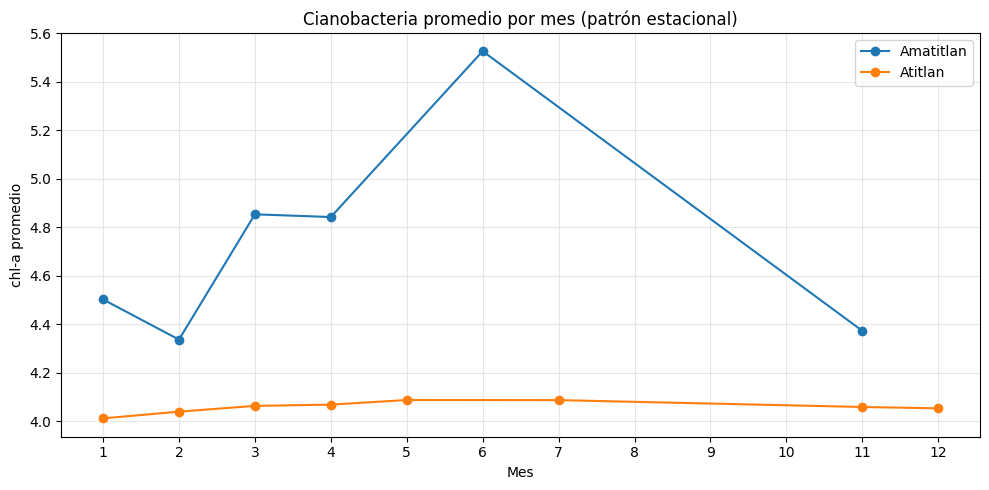

In [26]:
# 8.4: patrón estacional. Guatemala tiene estación SECA (nov-abr) y LLUVIOSA (may-oct).
df_est = df_indices.copy()
df_est["mes"] = df_est["fecha"].dt.month
df_est["estacion"] = np.where(df_est["mes"].isin([5, 6, 7, 8, 9, 10]), "lluviosa", "seca")

# Promedio por lago y estación
tabla_estacion = (df_est.groupby(["lago", "estacion"])["cyano_prom"]
                  .agg(["mean", "count"]).round(3))
print("Cianobacteria promedio por estación:")
display(tabla_estacion)

# Promedio por mes (todas las fechas disponibles)
fig, ax = plt.subplots(figsize=(10, 5))
for lago, g in df_est.groupby("lago"):
    mensual = g.groupby("mes")["cyano_prom"].mean()
    ax.plot(mensual.index, mensual.values, marker="o", label=lago.capitalize())
ax.set_title("Cianobacteria promedio por mes (patrón estacional)")
ax.set_xlabel("Mes"); ax.set_ylabel("chl-a promedio")
ax.set_xticks(range(1, 13))
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("patron_estacional.png", dpi=150)
plt.show()

**Interpretación 8.4.** En **Amatitlán** se insinúa un patrón estacional: los valores más altos se concentran en la **transición de la estación seca a la lluviosa (abril–junio)**. Esto es consistente con dos mecanismos que se combinan: (1) el final de la seca deja el agua cálida, estancada y con nutrientes acumulados, y (2) **las primeras lluvias arrastran una carga fresca de nutrientes** desde la cuenca urbana. En **Atitlán** no se aprecia un patrón estacional claro: la señal es plana en ambas estaciones, coherente con la fuerte amortiguación del lago. *(Nota: con ~11 fechas por lago el patrón estacional es indicativo, no concluyente; se recomienda extender la serie a varios años para confirmarlo.)*

### 8.5. Síntesis del análisis exploratorio

Los análisis adicionales refuerzan de forma consistente el diagnóstico de los dos lagos:

- **Amatitlán** presenta una floración de cianobacteria **intensa, frecuente, en aumento y espacialmente concentrada** en el brazo noroeste (fuente urbana del río Villalobos), con su mayor extensión y sus distribuciones más elevadas en abril–junio de 2026. Es un caso de **eutrofización severa y estructural** que aporta una señal clara: el problema está ligado a una fuente puntual de nutrientes de origen urbano y tiende a agravarse.
- **Atitlán** se comporta como un sistema **estable y resiliente** en el período: baja extensión de valores altos, distribuciones estrechas y sin patrón estacional marcado, gracias a su gran profundidad y volumen. La señal indica que, aunque hay presión, el lago aún **amortigua** los aportes; conviene monitorearlo para detectar a tiempo cualquier cambio de tendencia.

En conjunto, el uso de imágenes Sentinel-2 y de los índices espectrales (índice de cianobacteria, NDVI, NDWI) permite **monitorear estas floraciones de forma remota, periódica y de bajo costo**, identificando dónde, cuándo y con qué intensidad ocurren, información esencial para orientar las decisiones de gestión ambiental y de salud pública.